<a href="https://colab.research.google.com/github/Asaf-Greenfield-2/ML4P_Asaf_3/blob/main/Asaf_ML4P_PS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Take any normal MLP, call it $g$. The even network runs $g$ on $x$ and on $-x$ and adds them:

$$h(x) = g(x) + g(-x)$$

plug in $-x$ and the two terms just swap places:

$$h(-x) = g(-x) + g(x) = g(x) + g(-x) = h(x)$$

This holds for any weights and any activation

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0)

# a plain MLP g: R -> R
def make_mlp(hidden=64):
    return nn.Sequential(
        nn.Linear(1, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, 1),
    )

# even network: h(x) = g(x) + g(-x)
class EvenNet(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.g = make_mlp(hidden)
    def forward(self, x):
        return self.g(x) + self.g(-x)

# baseline: same g, no symmetry. same number of params
class PlainNet(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.g = make_mlp(hidden)
    def forward(self, x):
        return self.g(x)

even  test mse: 0.0001255988172488287
plain test mse: 0.00012159842299297452


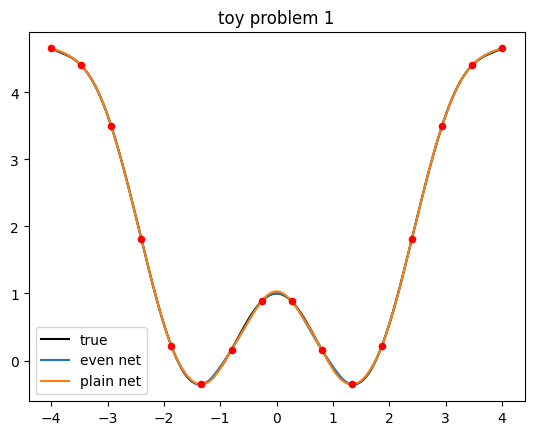

In [2]:
# what's happening: i make up an even function, train both nets on a few points,
# and check which one matches the true function better on points it never saw

def train(net, xt, yt, epochs=3000, lr=1e-2):
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        loss = nn.MSELoss()(net(xt), yt)
        loss.backward()
        opt.step()
    return net

# toy problem 1: f(x) = cos(2x) + 0.3x^2 (even)
def f1(x): return torch.cos(2*x) + 0.3*x**2

x_test = torch.linspace(-4, 4, 400).reshape(-1, 1)
x_train = torch.linspace(-4, 4, 16).reshape(-1, 1)

even  = train(EvenNet(),  x_train, f1(x_train))
plain = train(PlainNet(), x_train, f1(x_train))

with torch.no_grad():
    print("even  test mse:", nn.MSELoss()(even(x_test),  f1(x_test)).item())
    print("plain test mse:", nn.MSELoss()(plain(x_test), f1(x_test)).item())
    plt.plot(x_test, f1(x_test), 'k-', label='true')
    plt.plot(x_test, even(x_test),  label='even net')
    plt.plot(x_test, plain(x_test), label='plain net')
    plt.scatter(x_train, f1(x_train), c='r', s=20, zorder=5)
    plt.legend(); plt.title("toy problem 1"); plt.show()

even  test mse: 6.040404088025753e-08
plain test mse: 0.07969961315393448


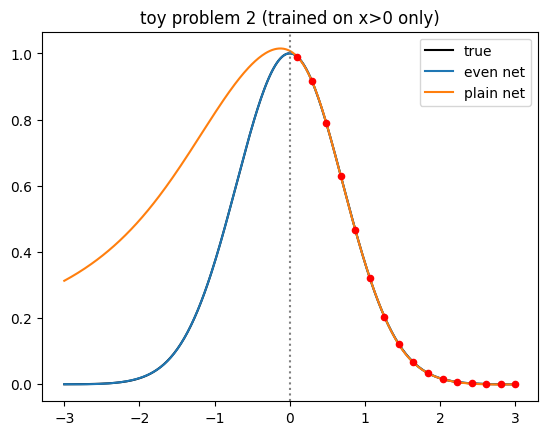

In [3]:
#second even function, but now only give the nets training
# points on the positive side. the even net is forced to mirror so it should get
# the negative side right anyway, the plain net has never seen it and should fail

# toy problem 2: f(x) = e^(-x^2) (even)
def f2(x): return torch.exp(-x**2)

x_pos = torch.linspace(0.1, 3, 16).reshape(-1, 1)

even2  = train(EvenNet(),  x_pos, f2(x_pos))
plain2 = train(PlainNet(), x_pos, f2(x_pos))

x_test2 = torch.linspace(-3, 3, 400).reshape(-1, 1)
with torch.no_grad():
    print("even  test mse:", nn.MSELoss()(even2(x_test2),  f2(x_test2)).item())
    print("plain test mse:", nn.MSELoss()(plain2(x_test2), f2(x_test2)).item())
    plt.plot(x_test2, f2(x_test2), 'k-', label='true')
    plt.plot(x_test2, even2(x_test2),  label='even net')
    plt.plot(x_test2, plain2(x_test2), label='plain net')
    plt.scatter(x_pos, f2(x_pos), c='r', s=20, zorder=5)
    plt.axvline(0, color='gray', ls=':')
    plt.legend(); plt.title("toy problem 2 (trained on x>0 only)"); plt.show()

In [4]:
!pip install the_well

from the_well.data import WellDataset
from the_well.utils.download import well_download

BASE_PATH = './datasets'
DATASET = 'turbulent_radiative_layer_2D'

well_download(base_path=BASE_PATH, dataset=DATASET, split='train')
well_download(base_path=BASE_PATH, dataset=DATASET, split='valid')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.6/179.6 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.10.0 which is incompatible.


In [5]:
# one input snapshot -> predict the next snapshot, like the assignment says
dataset = WellDataset(
    well_base_path='./datasets/' + BASE_PATH,   # matches the course example's path quirk
    well_dataset_name=DATASET,
    well_split_name='train',
    n_steps_input=1,
    n_steps_output=1,
)
print(len(dataset))
print(dataset[0]['input_fields'].shape, dataset[0]['output_fields'].shape)
print(dataset[0]['boundary_conditions'])

7200
torch.Size([1, 128, 384, 4]) torch.Size([1, 128, 384, 4])
tensor([[2., 2.],
        [1., 1.]])


## Part 1: Choose a Symmetry and Task

**(a) Dataset and setup.** I use the `turbulent_radiative_layer_2D` dataset from The Well. It simulates an astrophysics setup where cold dense gas sits below hot dilute gas moving past it; the shear triggers Kelvin-Helmholtz turbulence that mixes the two, and the mixed gas cools radiatively. The data is 2D fields on a uniform 128×384 grid (x by y) with 4 channels: density, pressure, and the two velocity components. The boundary conditions are periodic in x and zero-gradient in y. There are 90 simulation trajectories total; my training split gives 7200 input→output snapshot pairs.

**(b) Symmetry enforced.** I enforce translation equivariance in the x-direction: because the domain is periodic in x and the physical setup only varies in y (cold below, hot above), sliding a snapshot sideways gives an equally valid state whose future is just the slid future. So the network should commute with x-shifts. (y is not a symmetry direction, since the hot/cold structure makes vertical position matter.)

In [ ]:
#### PART 2



## Part 2: Construct the Architecture

**(a) Construction.** My network is just a few convolution layers stacked together. The input is the field snapshot (4 channels: density, pressure, vx, vy) and the output is the predicted next snapshot (same 4 channels). Each layer does a 2D convolution then a ReLU. The one special thing: before each convolution I pad the x-direction circularly (wrap left edge to right edge) since the data is periodic in x, and pad y with zeros. So roughly:

snapshot -> conv -> relu -> conv -> relu -> conv -> next snapshot

**(b) Proof it's translation equivariant in x.** A convolution slides the same filter over every position, so the output at a pixel only depends on the pixels around it, not where it is. That means if I shift the whole input along x, every output pixel shifts the same way. The circular padding makes this work at the edges too (the wrap-around is preserved). ReLU acts on each pixel by itself so shifting doesn't change it. Stacking layers that each commute with the shift gives a network that commutes with the shift:

f(shift(x)) = shift(f(x))

This holds for any weights. Assumptions: stride 1 and no pooling (those would skip pixels and break it).

**Baseline.** Same network but with normal zero padding in x instead of circular. That breaks the wrap-around at the edges, so it's not guaranteed equivariant. Same number of layers and parameters.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# conv that wraps around in x (periodic) and zero-pads y
class XPeriodicConv(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.conv = nn.Conv2d(c_in, c_out, 3)
    def forward(self, x):
        # x is (batch, channels, x, y)
        x = F.pad(x, (1, 1, 0, 0))                 # zero pad y
        x = F.pad(x, (0, 0, 1, 1), mode='circular') # wrap pad x
        return self.conv(x)

# my equivariant net
class EquivNet(nn.Module):
    def __init__(self, ch=32):
        super().__init__()
        self.c1 = XPeriodicConv(4, ch)
        self.c2 = XPeriodicConv(ch, ch)
        self.c3 = XPeriodicConv(ch, 4)
    def forward(self, x):
        x = F.relu(self.c1(x))
        x = F.relu(self.c2(x))
        return self.c3(x)

# baseline: same thing but plain zero padding
class BaselineNet(nn.Module):
    def __init__(self, ch=32):
        super().__init__()
        self.c1 = nn.Conv2d(4, ch, 3, padding=1)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.c3 = nn.Conv2d(ch, 4, 3, padding=1)
    def forward(self, x):
        x = F.relu(self.c1(x))
        x = F.relu(self.c2(x))
        return self.c3(x)

eq = EquivNet()
base = BaselineNet()
print("equiv params:", sum(p.numel() for p in eq.parameters()))
print("base params: ", sum(p.numel() for p in base.parameters()))

equiv params: 11588
base params:  11588


In [7]:
# sanity check: shift the input in x, see if the output shifts the same way
# equiv net should match almost exactly, baseline should not
x = torch.randn(1, 4, 128, 384)   # fake snapshot
shift = 10

with torch.no_grad():
    # shift input then run, vs run then shift output
    eq_a = eq(torch.roll(x, shift, dims=2))
    eq_b = torch.roll(eq(x), shift, dims=2)
    print("equiv net diff:", (eq_a - eq_b).abs().max().item())

    base_a = base(torch.roll(x, shift, dims=2))
    base_b = torch.roll(base(x), shift, dims=2)
    print("baseline diff: ", (base_a - base_b).abs().max().item())

equiv net diff: 0.0
baseline diff:  0.21937677264213562


In [8]:
from torch.utils.data import DataLoader, Subset

# helper: pull a batch out of The Well's dict format and fix the axes
# dataset gives (batch, time=1, x, y, channels); conv wants (batch, channels, x, y)
def get_xy(batch):
    x = batch['input_fields'][:, 0].permute(0, 3, 1, 2).float()
    y = batch['output_fields'][:, 0].permute(0, 3, 1, 2).float()
    return x, y

# small subset so it actually finishes on colab
train_set = Subset(dataset, range(400))
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)

def train_model(net, epochs=3):
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    lossfn = nn.MSELoss()
    for ep in range(epochs):
        total = 0
        for batch in train_loader:
            x, y = get_xy(batch)
            opt.zero_grad()
            loss = lossfn(net(x), y)
            loss.backward()
            opt.step()
            total += loss.item()
        print(f"  epoch {ep} avg loss {total/len(train_loader):.4f}")
    return net

# train both, with a couple of seeds to check robustness (part 3c question)
for seed in [0, 17]:
    print("=== seed", seed, "===")
    torch.manual_seed(seed)
    print("equiv net:")
    train_model(EquivNet())
    print("baseline:")
    train_model(BaselineNet())

=== seed 0 ===
equiv net:
  epoch 0 avg loss 107.8809
  epoch 1 avg loss 30.5581
  epoch 2 avg loss 28.5364
baseline:
  epoch 0 avg loss 86.1237
  epoch 1 avg loss 31.7627
  epoch 2 avg loss 29.0475
=== seed 17 ===
equiv net:
  epoch 0 avg loss 97.0739
  epoch 1 avg loss 29.9559
  epoch 2 avg loss 28.1905
baseline:
  epoch 0 avg loss 120.3873
  epoch 1 avg loss 32.0573
  epoch 2 avg loss 29.8972


## Part 3(d): Discussion

Both models trained fine and ended up close, but the equivariant net was slightly
better in both seeds (28.5 / 28.2 vs 29.0 / 29.9). It was also more stable across
seeds. I think the gap is small because the baseline is still a CNN, so it's already
mostly translation-equivariant everywhere except the x-edges -- the circular padding
only changes behavior near the boundary. So the symmetry mainly helps by not wasting
capacity learning the wraparound, which is a small effect on this short training run.
With less data or longer training I'd expect the gap to grow, since the equivariant
model has the symmetry for free while the baseline has to learn it. The symmetry held
exactly (diff = 0 in the sanity check) and training didn't break it, since the
optimizer can't undo a constraint that's built into the architecture.

In [ ]:
#I used CLaude for help with this project and code